In [24]:
import opendatasets as od
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , Dense , Flatten, MaxPooling2D,BatchNormalization, GlobalAveragePooling2D, Dropout

In [25]:
od.download('https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification')

Skipping, found downloaded files in "./fruits-fresh-and-rotten-for-classification" (use force=True to force download)


In [26]:
train_ds= tf.keras.utils.image_dataset_from_directory(
"/content/fruits-fresh-and-rotten-for-classification/dataset/train"
,
image_size=(224,224),
batch_size = 32, )
test_ds= tf.keras.utils.image_dataset_from_directory(
"/content/fruits-fresh-and-rotten-for-classification/dataset/test",
image_size=(224,224),
batch_size = 32,)

Found 10901 files belonging to 6 classes.
Found 2698 files belonging to 6 classes.


In [27]:
train_ds = train_ds.map(lambda x,y : (x /255.0,y))
test_ds = test_ds.map(lambda x,y : (x /255.0,y))

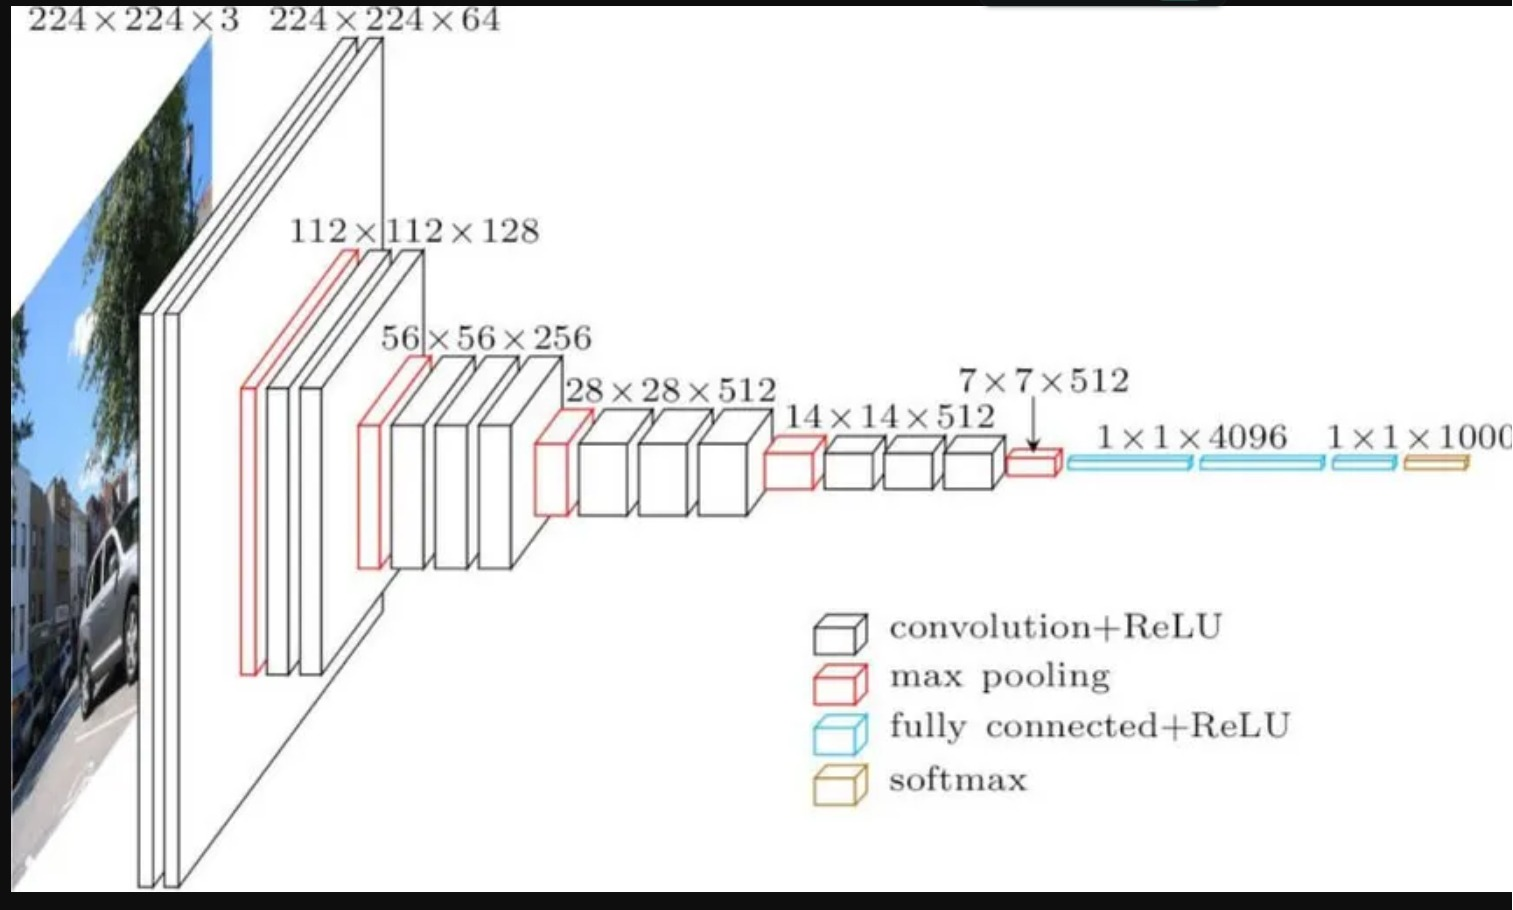

##VGG

In [28]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same',input_shape=(224, 224, 3)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Conv2D(128,(3,3), activation='relu', padding='same'),
    Conv2D(128,(3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Conv2D(256,(3,3), activation='relu', padding='same'),
    Conv2D(256,(3,3), activation='relu', padding='same'),
    Conv2D(256,(3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Conv2D(512,(3,3), activation='relu', padding='same'),
    Conv2D(512,(3,3), activation='relu', padding='same'),
    Conv2D(512,(3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Conv2D(512,(3,3), activation='relu', padding='same'),
    Conv2D(512,(3,3), activation='relu', padding='same'),
    Conv2D(512,(3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(4096, activation='relu'),
    Dense(4096, activation='relu'),
    Dense(6, activation='softmax')

])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy' ,metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.fit(train_ds,epochs=15)

Epoch 1/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 179s 496ms/step - accuracy: 0.2086 - loss: 1.8320
Epoch 2/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 163s 479ms/step - accuracy: 0.2097 - loss: 1.7765
Epoch 3/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 163s 478ms/step - accuracy: 0.2136 - loss: 1.7764
Epoch 4/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 163s 478ms/step - accuracy: 0.2145 - loss: 1.7759
Epoch 5/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 163s 476ms/step - accuracy: 0.2127 - loss: 1.7760
Epoch 6/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 163s 477ms/step - accuracy: 0.2137 - loss: 1.7760
Epoch 7/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 163s 477ms/step - accuracy: 0.2129 - loss: 1.7760
Epoch 8/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 163s 477ms/step - accuracy: 0.2131 - loss: 1.7759
Epoch 9/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 163s 476ms/step - accuracy: 0.2129 - loss: 1.7759
Epoch 10/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 163s 476ms/step - accuracy: 0.2111 - loss: 1.7758
Epoch 11/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 163s 476ms/step - accuracy: 0.2118 - loss: 1.7758
Epoch 12

In [30]:
model.evaluate(test_ds)

85/85 ━━━━━━━━━━━━━━━━━━━━ 16s 167ms/step - accuracy: 0.2228 - loss: 1.7759


[1.775873064994812, 0.22275759279727936]

##Modified VGG

Changes from the original VGG:
- **Fewer conv blocks (4 instead of 5) and smaller filter sizes (32→64→128→256 instead of
  64→128→256→512→512)** — my problem is simpler (6 classes, not 1000) and my dataset is smaller
  (~11k images), so a lighter network reduces overfitting and trains faster without losing accuracy.
- **BatchNormalization after every conv layer** — deep networks trained from scratch have
  unstable gradients; without it, training got stuck at loss ≈ ln(6), i.e. random guessing.
  BatchNorm fixes this.
- **GlobalAveragePooling2D instead of Flatten** — fewer parameters, less overfitting.
- **Smaller Dense layer (256) with Dropout (0.5)** — matches the reduced complexity of the task
  and adds regularization since the dataset is relatively small.

In [31]:
model2 = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model2.compile(optimizer='adam',loss='sparse_categorical_crossentropy' ,metrics=['accuracy'])

In [32]:
model2.fit(train_ds,epochs=15)

Epoch 1/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 72s 177ms/step - accuracy: 0.8021 - loss: 0.5836
Epoch 2/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 55s 162ms/step - accuracy: 0.8638 - loss: 0.3911
Epoch 3/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 55s 161ms/step - accuracy: 0.8962 - loss: 0.2952
Epoch 4/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 55s 161ms/step - accuracy: 0.9046 - loss: 0.2644
Epoch 5/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 55s 161ms/step - accuracy: 0.9198 - loss: 0.2257
Epoch 6/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 55s 161ms/step - accuracy: 0.9295 - loss: 0.1970
Epoch 7/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 55s 161ms/step - accuracy: 0.9388 - loss: 0.1711
Epoch 8/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 55s 160ms/step - accuracy: 0.9398 - loss: 0.1647
Epoch 9/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 55s 161ms/step - accuracy: 0.9447 - loss: 0.1602
Epoch 10/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 55s 161ms/step - accuracy: 0.9554 - loss: 0.1253
Epoch 11/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 55s 161ms/step - accuracy: 0.9620 - loss: 0.1180
Epoch 12/15
341/341

In [33]:
model2.evaluate(test_ds)

85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.8721 - loss: 0.4171


[0.41705965995788574, 0.8721274733543396]